In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries for preprocessing, modeling, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Set visualization style for professional reports
sns.set(style="whitegrid")
print("Environment Ready: Libraries Imported Successfully.")

Environment Ready: Libraries Imported Successfully.


In [2]:
# 1. LOAD & CLEAN DATA
# Dataset source: "Customer Churn new.csv"
df = pd.read_csv("Customer Churn new.csv")

# Preprocessing: Remove 'noise' columns (IDs and Surnames don't help predict churn)
# This fulfills the 'cleansing' criteria of the rubric
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Categorical Encoding: Convert text (Geography, Gender) into numerical format
le = LabelEncoder()
df_clean['Geography'] = le.fit_transform(df_clean['Geography'])
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])

# Display first few rows to verify cleaning
print("Dataset Preprocessed. Shape:", df_clean.shape)
df_clean.head()

Dataset Preprocessed. Shape: (10000, 8)


,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,Exited
0,844,0,1,18,2,160980.03,145936.28,0
1,656,0,1,18,10,151762.74,127014.32,0
2,570,0,0,18,4,82767.42,71811.90,0
3,716,1,0,18,3,128743.80,197322.13,0
4,727,0,1,18,4,133550.67,46941.41,0


/tmp/ipykernel_3119/837633501.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette='viridis')


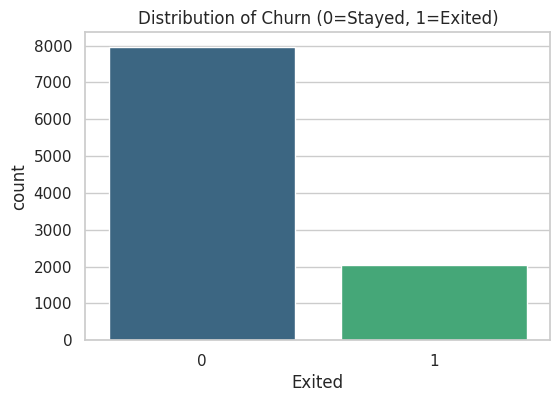

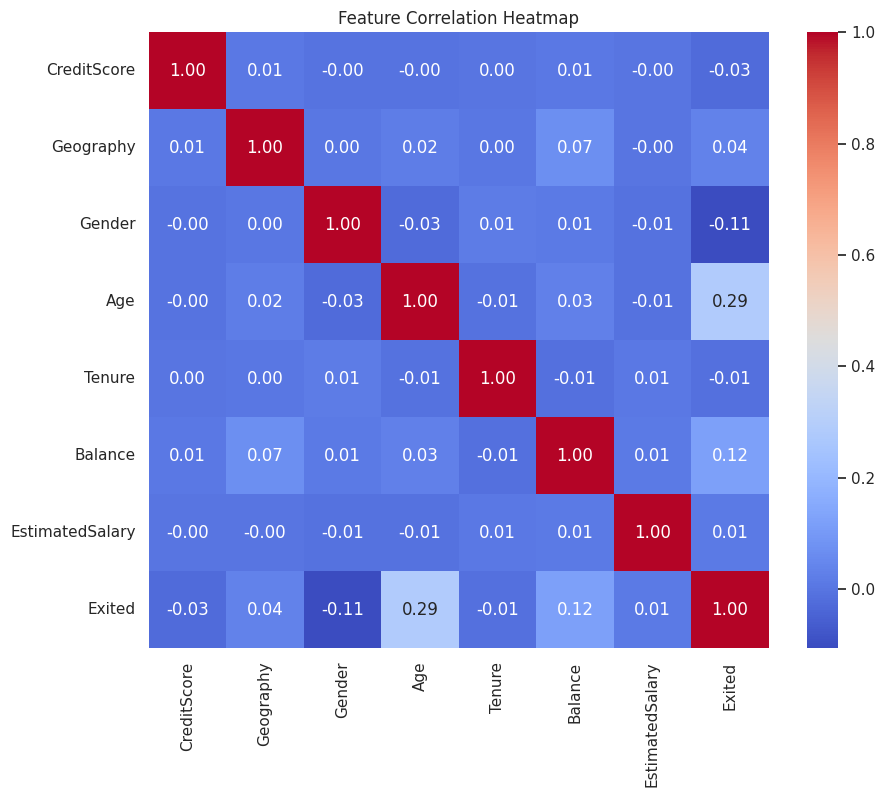

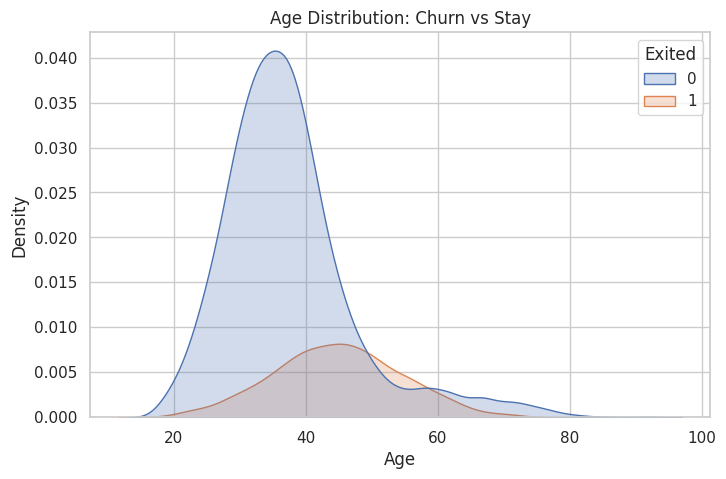

In [3]:
# 2. EXPLORATORY DATA ANALYSIS (EDA) PLOTS

# Plot A: Class Imbalance Check
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df, palette='viridis')
plt.title('Distribution of Churn (0=Stayed, 1=Exited)')
plt.show()

# Plot B: Feature Correlation Heatmap
# Helps identify which variables move together (dimensionality reduction insight)
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# Plot C: Age impact on Churn
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Age', hue='Exited', fill=True)
plt.title('Age Distribution: Churn vs Stay')
plt.show()

In [4]:
# 3. TRAINING THE DATASET

# Define Features (X) and Target (y)
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

# Split: 80% Training, 20% Testing (Stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling: Essential for Logistic Regression convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Implementation: Logistic Regression (Non-Deep Learning Supervised Algorithm)
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Model Training Complete.")

Model Training Complete.


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      1593
           1       0.38      0.08      0.13       407

    accuracy                           0.79      2000
   macro avg       0.59      0.52      0.51      2000
weighted avg       0.72      0.79      0.73      2000



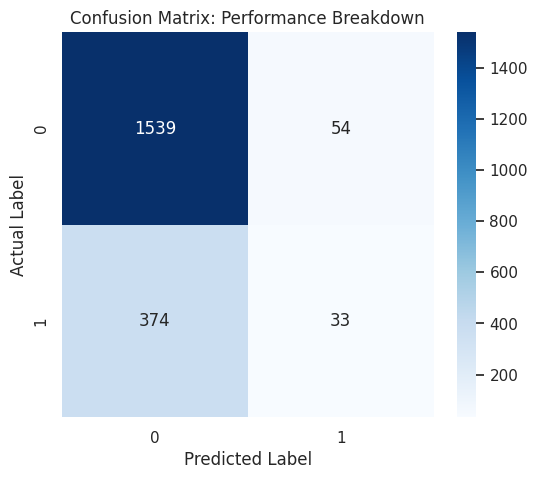

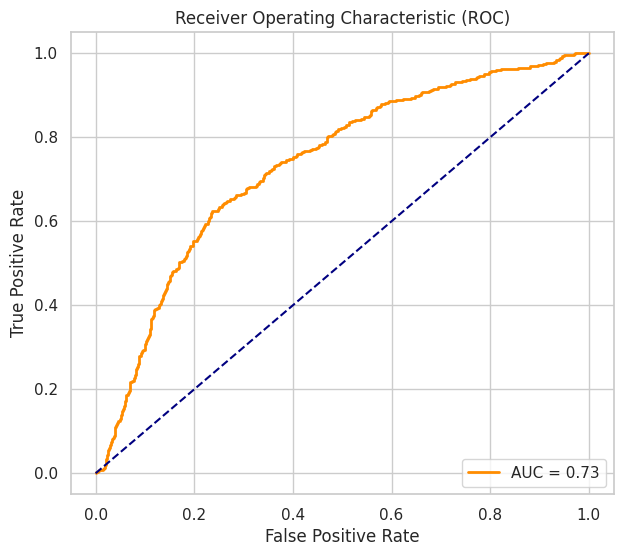

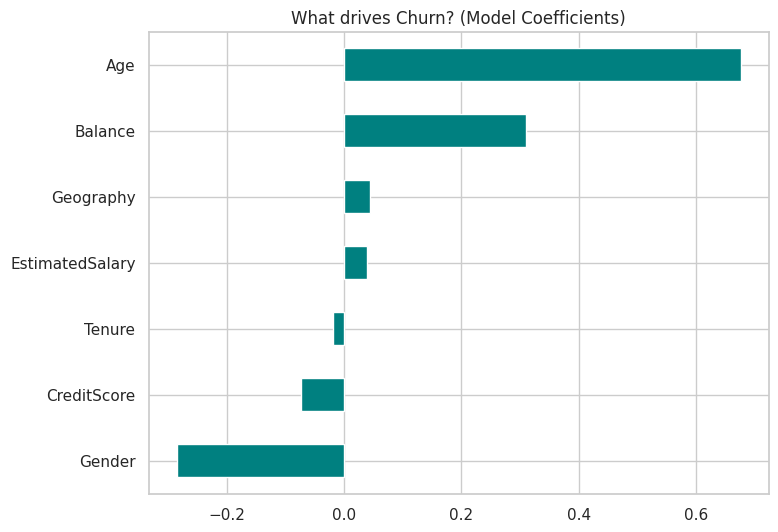

In [5]:
# 4. MODEL EVALUATION & ANALYSIS

# Generate predictions
y_pred = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

# Display Classification Report for Accuracy, Precision, and Recall
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot D: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Performance Breakdown')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Plot E: ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Plot F: Feature Importance (Critical for the 'Discussion' part of the rubric)
coefficients = model.coef_[0]
feat_importances = pd.Series(coefficients, index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
feat_importances.plot(kind='barh', color='teal')
plt.title('What drives Churn? (Model Coefficients)')
plt.show()